# Multi-Layer Perceptron

## Enunciado

Base de Dados do Período - [Stellar Classification Dataset - SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)

1. Atividade obrigatória:

   1. Criar uma rede neural de classificação entre galáxias, quasares e estrelas usando TensorFlow ou PyTorch

   2. Testar o efeito de se variar a largura e a profundidade da rede neural;

   3. Treine o modelo testando diferentes valores de épocas e learning rate, identificando quando se acontece overfitting ou underfitting;

   4. Testar o efeito da Regularização e outros métodos de otimização;

2. Atividades sugeridas:

   1. Aplicar as técnicas em outro conjunto de dados como os, que podem ser importados diretamente para o notebook através do Keras.

   2. Criar uma rede neural “from scratch” de classificação e aplique no dataset. Use como embasamento a playlist Neural Networks from Scratch in Python:

      1. A rede deve conter uma camada oculta (quantidade de neurônios a critério)

      2. Separe a label das features e o dataset em subsets de treinamento e teste;

      3. Inicialização randômica dos pesos;

      4. Defina a função de ativação e calcular sua derivada (Sinta-se à vontade para experimentar mais de uma);

      5. Treine o modelo testando diferentes valores de épocas e learning rate, identificando quando acontece Overfitting e Underfitting. Fazer as previsões nos dados de teste e avaliar o modelo.


## Setup


### Importando bibliotecas e dados


In [1]:
# Importando bibliotecas
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.api.datasets import mnist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.optim import Adam
from torchmetrics import Metric, Accuracy

In [2]:
# Importando dados
df = pd.read_csv('../datasets/star_classification.csv')

### Definindo dispositivo


In [3]:
# Using gpu if available
device = 'mps' if torch.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


### Funções


In [4]:
# Função para treinamento de modelo
def training_loop(
    estimator: nn.Module,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    train_data: Tuple[torch.Tensor, torch.Tensor],
    metric: Metric | None = None,
    validation_split: float | None = None,
    seed: int | None = None,
    print_every: int = 10,
) -> Dict[str, List[float]]:

    if seed is not None:
        torch.manual_seed(seed)

    X_train, y_train = train_data
    if validation_split is not None:
        X_train, X_val, y_train, y_val = train_test_split(
            X_train,
            y_train,
            test_size=validation_split,
            random_state=seed,
        )

    data_tracking = {
        'train_loss': [],
        'train_metric': [],
        'val_loss': [],
        'val_metric': [],
    }

    validation_print = ''

    for epoch in range(epochs):
        estimator.train()

        train_logits = estimator(X_train)
        train_preds = train_logits.argmax(dim=1)

        training_loss = loss_fn(train_logits, y_train)
        data_tracking['train_loss'].append(training_loss)

        if metric is not None:
            training_metric = metric(train_preds, y_train)
            data_tracking['train_metric'].append(training_metric)

        optimizer.zero_grad()
        training_loss.backward()

        optimizer.step()

        if validation_split is not None:
            with torch.inference_mode():
                estimator.eval()
                val_logits = estimator(X_val)
                val_preds = val_logits.argmax(dim=1)
                validation_loss = loss_fn(val_logits, y_val)
                data_tracking['val_loss'].append(validation_loss)

            if metric is not None:
                validation_metric = metric(val_preds, y_val)
                data_tracking['val_metric'].append(validation_metric)

                val_metric_print = (
                    f' Validation {metric._get_name()}: {validation_metric:.2f} |'
                )

            validation_print = f' Validation loss: {validation_loss:.2f} |'

        train_metric_print = f' Training {metric._get_name()}: {training_metric:.2f} |'

        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(
                f'| Epoch: {epoch + 1} |',
                '-' * 121,
                f'| Training loss: {training_loss:.2f} |'
                + train_metric_print
                + validation_print
                + val_metric_print,
                '-' * 121,
                sep='\n',
                end='\n\n',
            )

    return data_tracking

In [5]:
# Função para criar gráficos da perda e da acurácia de um modelo
def plot_loss_acc(
    epoch_range: List[int],
    train_losses: np.ndarray,
    test_losses: np.ndarray,
    train_acc: np.ndarray,
    test_acc: np.ndarray,
    figsize: Tuple[int, int],
) -> None:
    # Plotting loss functions
    _, (ax_1, ax_2) = plt.subplots(1, 2, figsize=figsize)
    ax_1.plot(epoch_range, train_losses, label='Train loss')
    ax_1.plot(epoch_range, test_losses, label='Test loss')
    ax_1.set_title('Loss values over training epochs')
    ax_1.grid(True)
    ax_1.legend()

    # Plotting loss functions
    ax_2.plot(epoch_range, train_acc, label='Train accuracy')
    ax_2.plot(epoch_range, test_acc, label='Test accuracy')
    ax_2.set_title('Accuracy values over training epochs')
    ax_2.legend()
    ax_2.grid(True)

    plt.show()

## EDA

Foi feita uma breve análise sobre as distribuições dos dados, e a contagem de entradas por label. Em seguida, a label `class` foi codificada da seguinte maneira:

- `GALAXY` --> 0
- `STAR` --> 1
- `QSO` --> 2

Posteriormente, as features foram normalizados, de modo que suas médias são 0 e seu desvio padrão 1. Finalmente foram transformadas de `np.ndarray` para `torch.Tensor`, e separadas entre treino e teste, com esse último passo sendo também aplicado nas labels.


In [6]:
# Visualizando dados
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [7]:
# Descrevendo distribuições de dados
df.describe().round(2)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,1.000000e+05,100000.00,100000.00,100000.00,100000.00
mean,1.237665e+18,177.63,24.14,21.98,20.53,19.65,19.08,18.67,4481.37,301.0,3.51,186.13,5.783882e+18,0.58,5137.01,55588.65,449.31
std,8.438560e+12,96.50,19.64,31.77,31.75,1.85,1.76,31.73,1964.76,0.0,1.59,149.01,3.324016e+18,0.73,2952.30,1808.48,272.50
min,1.237646e+18,0.01,-18.79,-9999.00,-9999.00,9.82,9.47,-9999.00,109.00,301.0,1.00,11.00,2.995191e+17,-0.01,266.00,51608.00,1.00
25%,1.237659e+18,127.52,5.15,20.35,18.97,18.14,17.73,17.46,3187.00,301.0,2.00,82.00,2.844138e+18,0.05,2526.00,54234.00,221.00
50%,1.237663e+18,180.90,23.65,22.18,21.10,20.13,19.41,19.00,4188.00,301.0,4.00,146.00,5.614883e+18,0.42,4987.00,55868.50,433.00
75%,1.237668e+18,233.90,39.90,23.69,22.12,21.04,20.40,19.92,5326.00,301.0,5.00,241.00,8.332144e+18,0.70,7400.25,56777.00,645.00
max,1.237681e+18,360.00,83.00,32.78,31.60,29.57,32.14,29.38,8162.00,301.0,6.00,989.00,1.412694e+19,7.01,12547.00,58932.00,1000.00


In [8]:
# Verificando distribuição de classes
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [9]:
# Criando cópia do dataset
df_copy = df.copy(deep=True)

In [10]:
# Codificando coluna 'class'
df_copy['class'] = df_copy['class'].map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})

In [11]:
# Separar dados com holdout
X = df_copy.drop('class', axis=1)
y = df_copy['class']

In [12]:
# Normalizando dados
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [13]:
# Transformando arrays em tensors
X = torch.from_numpy(X).type(torch.float32).to(device)
y = torch.from_numpy(y.to_numpy()).type(torch.float32).to(device)

In [14]:
# Separando dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## Construindo modelo

A arquitetura construida na classe `ArtificialNeuralNetwork`, é uma rede neural simples, que segue a seguinte função:

$$a_n = \sigma{(W_n\times x + B_n)}$$

Onde $a_n$ é a saída da $n$-$ésima$ camada, $\sigma$ é a função de ativação, $W_n$ é a matriz de peso da $n$-$ésima$ camada, e $B_n$ é a matriz de viéses $n$-$ésima$ camada.

A classe tem algumas opções de configuração, de forma a facilitar o teste com diferentes números de camadas (`inner_layer=True`), unidades ocultas (diferentes valores para `hidden_units`), e com ou sem normalização (atribuindo um valor a `dropout_p`).

Além desses, a classe possui também os seguintes parâmetros, `in_features` que configura o tamanho do vetor de entrada, e `num_classes` que define o tamanho do vetor de saída da rede (número de classes a serem previstas).


In [ ]:
# Definindo modelo
class ArtificialNeuralNetwork(nn.Module):
    def __init__(
        self,
        in_features: int,
        num_classes: int,
        hidden_units: int,
        inner_layer: bool = True,
        dropout_p: float = 0,
    ) -> None:
        super().__init__()

        # Camadas lineares
        self.layer_1 = nn.Linear(in_features=in_features, out_features=hidden_units)
        self.layer_2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer_3 = nn.Linear(in_features=hidden_units, out_features=num_classes)

        # Camada de ativação
        self.relu = nn.ReLU()

        # Regularização
        self.dropout = nn.Dropout(p=dropout_p)

        # Outros atributos
        self.inner_layer = inner_layer

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.layer_1(x)
        z = self.relu(z)
        z = self.dropout(z)

        if self.inner_layer:
            z = self.layer_2(z)
            z = self.relu(z)
            z = self.dropout(z)

        return self.layer_3(z)

### Analisando performance com diferentes hiperparâmetros

Para cada uma das duas opções de camadas, foram treinados 9 modelos, com diferentes _learning rates_ e diferentes números de unidades ocultas. Todos esses 18 modelos, no total, foram treinados em 150 épocas, (esse número de épocas foi obtido de forma empírica, após observação de quando os modelos tendiam a converter).

Os modelos de 2 camadas tiveram melhores resultados com _learning rate_ de 0.1, e $32$ unidades ocultas. Enquanto os modelos de 3 camadas obtiveram seu pico em performance com _learning rates_ de $0.01$ e $64$ unidades ocultas. Os dois modelos citados obtiveram métricas idênticas, com $0.11$ como valor de perda de treino, $0.12$ de validação, enquanto obtiveram $0.97$ de acurácia tanto para treino quanto para teste.

### Underfitting e Overfitting

Para analisar em que ponto os modelo fazem overfitting, os dois modelos com melhor performance citados acima, foram treinados por $1.000$ épocas, com intuito de analisar overfitting. O modelo de duas camadas (`model_2l`), teve um treinamento com diversos picos de valores na função de perda, e vales nos valores de acurácia. O modelo de três camadas (`model_3l`), teve um treinamento com um grande pico de valor da função de perda, e um breve vale no valor de acurácia.

Devido à distribuição dos dados, e à arquitetura do modelo, não foram obtidos em nenhum treinamento, discrepâncias entre os valores da função de perda dos dados de teste, assim como para os valores de acurácia entre os dois conjuntos. Isso leva à conclusão de que o modelo tem alta capacidade de generalização, com overfitting sendo muito improvável, mesmo após dezenas de milhares de épocas de treinamento.

Quanto a underfitting, a arquitetura já chega a valores altos de acurácia (~$0.9$), e baixos de perda (>$0.5$), com valores próximos a 150 épocas de forma geral a qualquer dos modelos treinados.

### Regularização

A arquitetura foi montada de forma a possibilitar a passagem do processamento por camadas de `dropout`. Esse método de regularização faz o "desligamento" de alguns neurônios durante o processamento, de forma a evitar overfitting.

Enquanto eram feitos os testes para overfitting dos modelos, foi simultaneamente realizado o mesmo processo em um modelo da mesma arquitetura, apenas adicionando camadas de `dropout`, uma no caso do modelo `model_2l`, e duas no modelo `model_3l`. A regularização foi posicionada após as funções de ativação de cada camada.

Os modelos já não tinham tendência a overfitting, mas a adição da regularização para cada camada, tornou o processo de treinamento mais estável. No primeiro modelo, ocorram menores picos e vales nos valores de perda e acurácia respectivamente, enquanto no segundo modelo os picos e vales foram muito pequenos. Esse comportamento evidencia a eficácia do método de dropout em obter um treinamento mais "imparcial", distribuindo a importância entre os neurônios de forma mais homogênea.


#### 2 Camadas

##### Learning rates com modelo `hidden_units=32`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.69          | 0.72                        | 0.69            | 0.72                          |
| 0.01          | 0.16          | 0.95                        | 0.16            | 0.95                          |
| 0.1           | 0.11          | 0.97                        | 0.12            | 0.97                          |

##### Learning rates com modelo `hidden_units=64`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.57          | 0.75                        | 0.57            | 0.77                          |
| 0.01          | 0.15          | 0.96                        | 0.15            | 0.96                          |
| 0.1           | 0.14          | 0.96                        | 0.14            | 0.96                          |

##### Learning rates com modelo `hidden_units=128`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.46          | 0.85                        | 0.45            | 0.85                          |
| 0.01          | 0.13          | 0.96                        | 0.13            | 0.96                          |
| 0.1           | 0.13          | 0.96                        | 0.13            | 0.96                          |


##### Configurando modelo


In [16]:
# Instanciando modelo
model_2l = ArtificialNeuralNetwork(
    in_features=17,
    num_classes=3,
    hidden_units=32,
).to(device)

model_2l_dropout = ArtificialNeuralNetwork(
    in_features=17,
    num_classes=3,
    hidden_units=32,
    dropout_p=0.2,
).to(device)

In [17]:
# Definido função de perda
loss_fn_2l = nn.CrossEntropyLoss()

# Definindo otimizador
optimizer_2l = Adam(
    params=model_2l.parameters(),
    lr=0.1,
)

optimizer_2l_dropout = Adam(
    params=model_2l_dropout.parameters(),
    lr=0.1,
)

In [18]:
# Definindo número de épocas
epochs = 1000

# Definindo acurácia
accuracy_2l = Accuracy(task='multiclass', num_classes=3).to(device)

##### Treinando modelo


In [19]:
# Treinando modelo
history_2l = training_loop(
    model_2l,
    optimizer=optimizer_2l,
    loss_fn=loss_fn_2l,
    epochs=epochs,
    train_data=(X_train, y_train),
    metric=accuracy_2l,
    validation_split=0.2,
    print_every=100,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 1.13 | Training MulticlassAccuracy: 0.23 | Validation loss: 1.58 | Validation MulticlassAccuracy: 0.59 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 100 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.12 | Training MulticlassAccuracy: 0.96 | Validation loss: 0.12 | Validation MulticlassAccuracy: 0.96 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 200 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.10 | Training MulticlassAccuracy: 0.97 | Validation loss: 0.11 | Validation Multic

In [20]:
# Treinando modelo
history_2l_dropout = training_loop(
    model_2l_dropout,
    optimizer=optimizer_2l_dropout,
    loss_fn=loss_fn_2l,
    epochs=epochs,
    train_data=(X_train, y_train),
    metric=accuracy_2l,
    validation_split=0.2,
    print_every=100,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 1.07 | Training MulticlassAccuracy: 0.55 | Validation loss: 1.54 | Validation MulticlassAccuracy: 0.59 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 100 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.19 | Training MulticlassAccuracy: 0.94 | Validation loss: 0.14 | Validation MulticlassAccuracy: 0.96 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 200 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.29 | Training MulticlassAccuracy: 0.93 | Validation loss: 0.20 | Validation Multic

##### Visualizando perda e acurácia


In [21]:
# Turning tensors into arrays
train_losses = torch.tensor(history_2l['train_loss']).cpu().numpy()
test_losses = torch.tensor(history_2l['val_loss']).cpu().numpy()
train_acc = torch.tensor(history_2l['train_metric']).cpu().numpy()
test_acc = torch.tensor(history_2l['val_metric']).cpu().numpy()

# Setting epoch range
epoch_range = [i for i in range(epochs)]

In [22]:
# Turning tensors into arrays
train_losses_dropout = torch.tensor(history_2l_dropout['train_loss']).cpu().numpy()
test_losses_dropout = torch.tensor(history_2l_dropout['val_loss']).cpu().numpy()
train_acc_dropout = torch.tensor(history_2l_dropout['train_metric']).cpu().numpy()
test_acc_dropout = torch.tensor(history_2l_dropout['val_metric']).cpu().numpy()

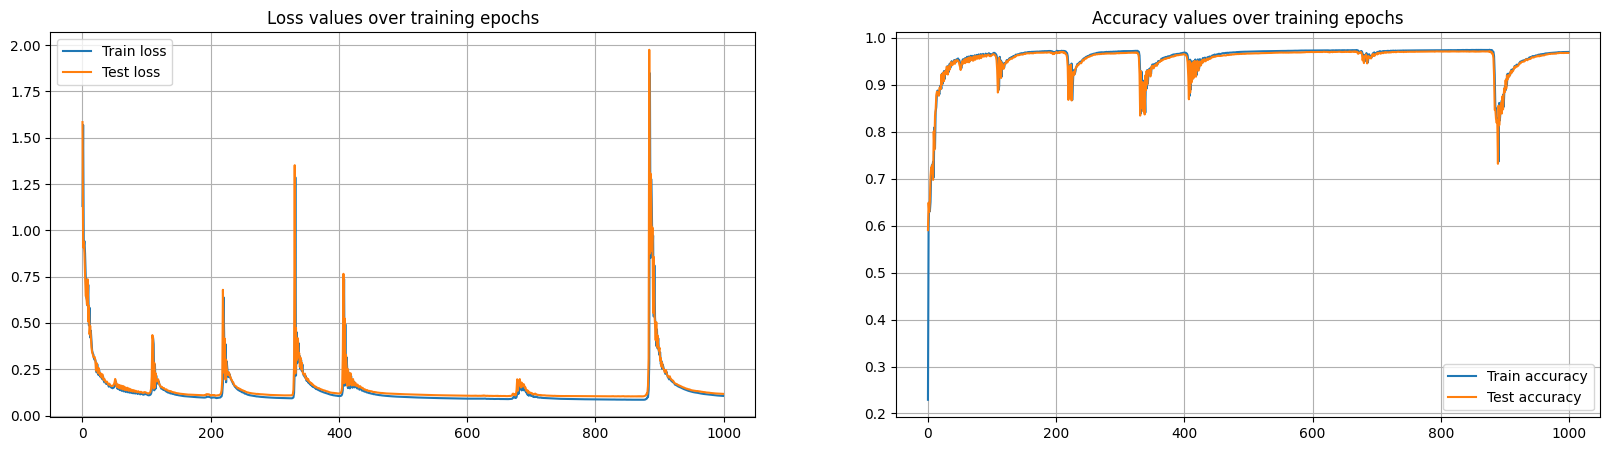

In [23]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range,
    train_losses,
    test_losses,
    train_acc,
    test_acc,
    figsize=(20, 5),
)

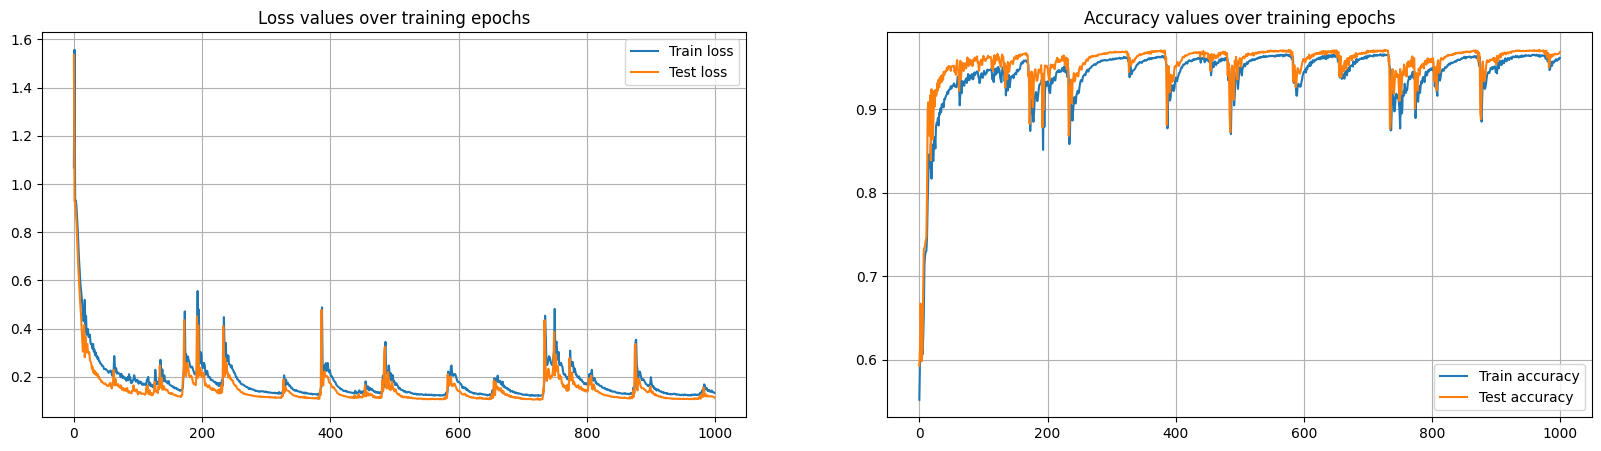

In [24]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range,
    train_losses_dropout,
    test_losses_dropout,
    train_acc_dropout,
    test_acc_dropout,
    figsize=(20, 5),
)

#### 3 Camadas

##### Learning rates com modelo `hidden_units=32`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.41          | 0.86                        | 0.41            | 0.86                          |
| 0.01          | 0.12          | 0.97                        | 0.12            | 0.97                          |
| 0.1           | 0.11          | 0.97                        | 0.12            | 0.97                          |

##### Learning rates com modelo `hidden_units=64`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.11          | 0.97                        | 0.13            | 0.96                          |
| 0.01          | 0.11          | 0.97                        | 0.12            | 0.97                          |
| 0.1           | 0.14          | 0.96                        | 0.15            | 0.96                          |

##### Learning rates com modelo `hidden_units=128`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.18          | 0.95                        | 0.18            | 0.95                          |
| 0.01          | 0.11          | 0.97                        | 0.13            | 0.96                          |
| 0.1           | 0.14          | 0.95                        | 0.13            | 0.96                          |


##### Configurando modelo


In [25]:
# Instanciando modelo
model_3l = ArtificialNeuralNetwork(
    in_features=17,
    num_classes=3,
    hidden_units=64,
).to(device)

model_3l_dropout = ArtificialNeuralNetwork(
    in_features=17,
    num_classes=3,
    hidden_units=64,
    dropout_p=0.2,
).to(device)

In [26]:
# Definido função de perda
loss_fn_3l = nn.CrossEntropyLoss()

# Definindo otimizador
optimizer_3l = Adam(
    params=model_3l.parameters(),
    lr=0.01,
)

optimizer_3l_dropout = Adam(
    params=model_3l_dropout.parameters(),
    lr=0.01,
)

In [27]:
# Definindo número de épocas
epochs = 1000

# Definindo acurácia
accuracy_3l = Accuracy(task='multiclass', num_classes=3).to(device)

##### Treinando modelo


In [28]:
# Treinando modelo
history_3l = training_loop(
    model_3l,
    optimizer=optimizer_3l,
    loss_fn=loss_fn_3l,
    epochs=epochs,
    train_data=(X_train, y_train),
    metric=accuracy_3l,
    validation_split=0.2,
    print_every=100,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 1.11 | Training MulticlassAccuracy: 0.31 | Validation loss: 1.01 | Validation MulticlassAccuracy: 0.64 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 100 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.12 | Training MulticlassAccuracy: 0.96 | Validation loss: 0.13 | Validation MulticlassAccuracy: 0.96 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 200 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.10 | Training MulticlassAccuracy: 0.97 | Validation loss: 0.11 | Validation Multic

In [29]:
# Treinando modelo
history_3l_dropout = training_loop(
    model_3l_dropout,
    optimizer=optimizer_3l_dropout,
    loss_fn=loss_fn_3l,
    epochs=epochs,
    train_data=(X_train, y_train),
    metric=accuracy_3l,
    validation_split=0.2,
    print_every=25,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 1.14 | Training MulticlassAccuracy: 0.18 | Validation loss: 1.02 | Validation MulticlassAccuracy: 0.58 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 25 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.39 | Training MulticlassAccuracy: 0.87 | Validation loss: 0.31 | Validation MulticlassAccuracy: 0.90 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 50 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.21 | Training MulticlassAccuracy: 0.93 | Validation loss: 0.17 | Validation Multicla

##### Visualizando perda e acurácia


In [30]:
# Turning tensors into arrays
train_losses = torch.tensor(history_3l['train_loss']).cpu().numpy()
test_losses = torch.tensor(history_3l['val_loss']).cpu().numpy()
train_acc = torch.tensor(history_3l['train_metric']).cpu().numpy()
test_acc = torch.tensor(history_3l['val_metric']).cpu().numpy()

# Setting epoch range
epoch_range = [i for i in range(epochs)]

In [31]:
# Turning tensors into arrays
train_losses_dropout = torch.tensor(history_3l_dropout['train_loss']).cpu().numpy()
test_losses_dropout = torch.tensor(history_3l_dropout['val_loss']).cpu().numpy()
train_acc_dropout = torch.tensor(history_3l_dropout['train_metric']).cpu().numpy()
test_acc_dropout = torch.tensor(history_3l_dropout['val_metric']).cpu().numpy()

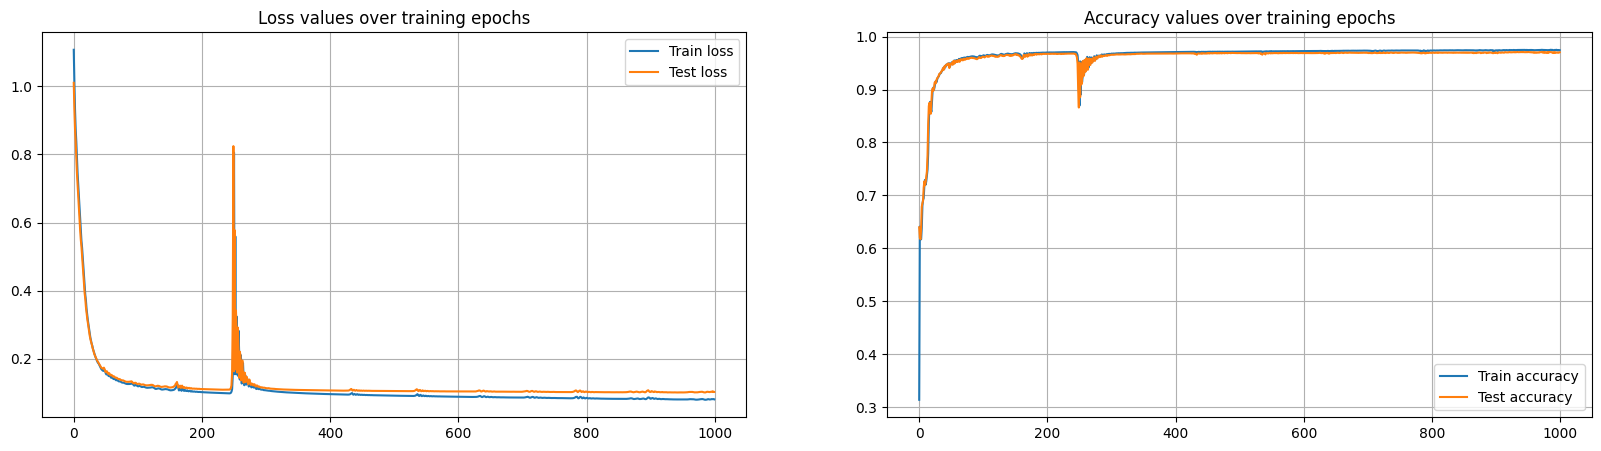

In [32]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range,
    train_losses,
    test_losses,
    train_acc,
    test_acc,
    figsize=(20, 5),
)

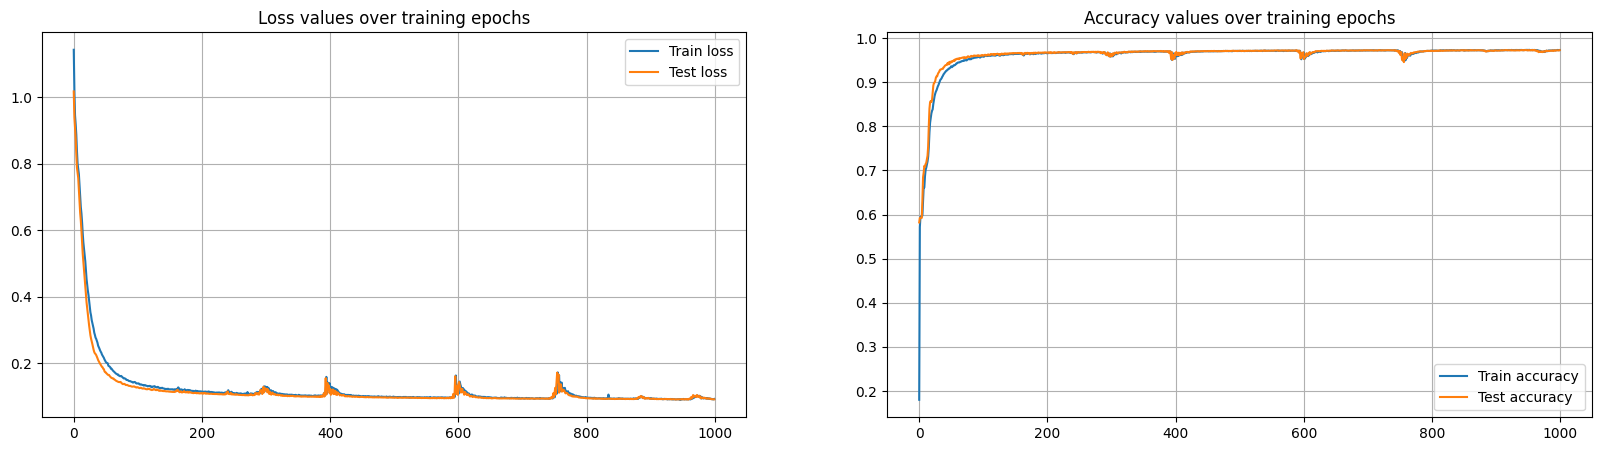

In [33]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range,
    train_losses_dropout,
    test_losses_dropout,
    train_acc_dropout,
    test_acc_dropout,
    figsize=(20, 5),
)

## Treinando modelo final

Após a análise de melhor performance dos modelos, foi feito uma modelagem completa com o modelo de 3 camadas, com dropout.


### Definindo otimizador, função de perda, métrica, e hiperparâmetros


In [34]:
# Instanciando modelo
model = ArtificialNeuralNetwork(
    in_features=17,
    num_classes=3,
    hidden_units=64,
    dropout_p=0.2,
).to(device)

In [35]:
# Definido função de perda
loss_fn = nn.CrossEntropyLoss()

# Definindo otimizador
optimizer = Adam(
    params=model.parameters(),
    lr=0.01,
)

In [36]:
# Definindo número de épocas
epochs = 150

# Definindo acurácia
accuracy = Accuracy(task='multiclass', num_classes=3).to(device)

#### Treinando modelo


In [37]:
# Treinando modelo
history = training_loop(
    model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    train_data=(X_train, y_train),
    metric=accuracy,
    validation_split=0.2,
    print_every=25,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 1.12 | Training MulticlassAccuracy: 0.22 | Validation loss: 1.01 | Validation MulticlassAccuracy: 0.60 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 25 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.36 | Training MulticlassAccuracy: 0.87 | Validation loss: 0.29 | Validation MulticlassAccuracy: 0.91 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 50 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.21 | Training MulticlassAccuracy: 0.93 | Validation loss: 0.17 | Validation Multicla

### Visualizações e previsões


#### Verificando previsões


In [38]:
# Obtendo previsões
with torch.inference_mode():
    model.eval()
    y_logits = model(X_test)
    y_preds = y_logits.argmax(dim=1).cpu()

y_true = y_test.cpu().numpy()

In [39]:
# Obtendo relatório de classificação
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97     11860
         1.0       0.95      1.00      0.97      4343
         2.0       0.96      0.90      0.93      3797

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



#### Visualizando perda e acurácia


In [40]:
# Turning tensors into arrays
train_losses = torch.tensor(history['train_loss']).cpu().numpy()
test_losses = torch.tensor(history['val_loss']).cpu().numpy()
train_acc = torch.tensor(history['train_metric']).cpu().numpy()
test_acc = torch.tensor(history['val_metric']).cpu().numpy()

# Setting epoch range
epoch_range = [i for i in range(epochs)]

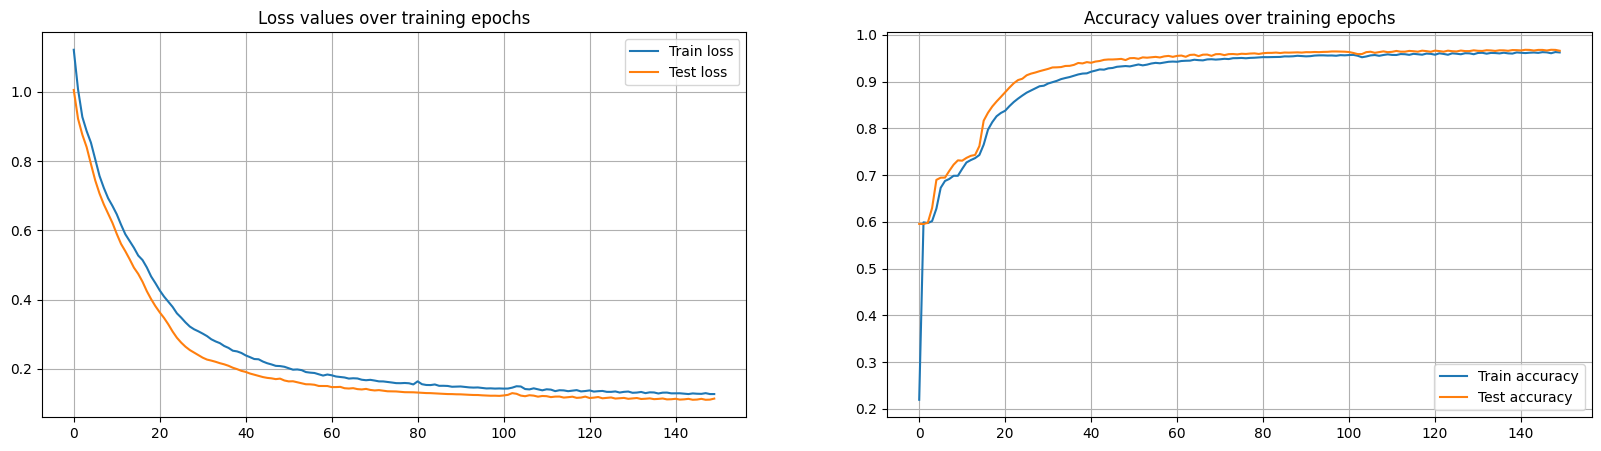

In [41]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range, train_losses, test_losses, train_acc, test_acc, figsize=(20, 5)
)

## Aplicando modelo em outro conjunto de dados

O dataset escolhido para aplicar o modelo, foi o **_MNIST digits classification dataset_**. Os dados são fotos de tamanho $28\times28$ de dígitos $0$-$9$. Esse dataset foi produzido pelo _Modified National Institute of Standards and Technology (MNIST)_, nos anos 90, ele contém $60.000$ imagens nos dados de treino,e $10.000$ imagens nos dados de teste.

Aqui foram feitos alguns passos para adaptação e implementação do algoritmo. Primeiramente foi feito um `reshape`, de forma que as imagens formassem vetores de forma $1\times784$ (devido a empilhamento das imagens $28\times28$ -> $784$).Em seguida foram feitas a normalização dos dados (dividindo-os por $255$, vez que estão em _grayscale_), e a transformação de `np.ndarray` para `torch.Tensor`. Após isso, o modelo foi feito com $3$ camadas e $64$ unidades ocultas.

Sua performance foi muito boa, com valores altíssimos (perto de $0.97$) de acurácia, e valores muito baixos de perda, tanto para os dados de treino quanto para os dados de teste (próximos a $0.1$), com apenas $100$ épocas de treinamento. Também não foi observado nenhum _over_ ou _underfitting_.


In [42]:
# Importando dados
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [43]:
# Normalizing data
X_train = X_train.reshape(60000, 784) / 255
X_test = X_test.reshape(10000, 784) / 255

In [44]:
# Instanciando novo modelo
mnist_model = ArtificialNeuralNetwork(
    in_features=784,
    num_classes=10,
    hidden_units=64,
    inner_layer=True,
).to(device)

In [45]:
# Instanciando função de perda
mnist_loss_fn = nn.CrossEntropyLoss()

# Instanciando otimizador
mnist_optimizer = Adam(
    params=mnist_model.parameters(),
    lr=0.01,
)

# Instanciando acurácia
mnist_acc = Accuracy('multiclass', num_classes=10).to(device)

# Definindo número de épocas
epochs = 100

In [46]:
# Transformando arrays em tensores
mnist_X_train = torch.from_numpy(X_train).type(torch.float32).to(device)
mnist_X_test = torch.from_numpy(X_test).type(torch.float32).to(device)
mnist_y_train = torch.from_numpy(y_train).type(torch.float32).to(device)
mnist_y_test = torch.from_numpy(y_test).type(torch.float32).to(device)

In [47]:
# Treinando modelo
mnist_history = training_loop(
    estimator=mnist_model,
    optimizer=mnist_optimizer,
    loss_fn=mnist_loss_fn,
    metric=mnist_acc,
    epochs=epochs,
    train_data=(mnist_X_train, mnist_y_train),
    validation_split=0.2,
    seed=42,
    print_every=10,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 2.31 | Training MulticlassAccuracy: 0.09 | Validation loss: 2.18 | Validation MulticlassAccuracy: 0.36 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 10 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.56 | Training MulticlassAccuracy: 0.82 | Validation loss: 0.54 | Validation MulticlassAccuracy: 0.83 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 20 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.37 | Training MulticlassAccuracy: 0.90 | Validation loss: 0.37 | Validation Multicla

#### Verificando previsões


In [48]:
# Obtendo previsões
with torch.inference_mode():
    mnist_model.eval()
    y_logits = mnist_model(mnist_X_test)
    y_preds = y_logits.argmax(dim=1).cpu()

y_true = mnist_y_test.cpu().numpy()

In [49]:
# Obtendo relatório de classificação
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       980
         1.0       0.98      0.98      0.98      1135
         2.0       0.96      0.95      0.95      1032
         3.0       0.95      0.96      0.95      1010
         4.0       0.96      0.96      0.96       982
         5.0       0.95      0.95      0.95       892
         6.0       0.96      0.96      0.96       958
         7.0       0.97      0.95      0.96      1028
         8.0       0.95      0.95      0.95       974
         9.0       0.96      0.95      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



#### Visualizando perda e acurácia


In [50]:
# Turning tensors into arrays
train_losses = torch.tensor(mnist_history['train_loss']).cpu().numpy()
test_losses = torch.tensor(mnist_history['val_loss']).cpu().numpy()
train_acc = torch.tensor(mnist_history['train_metric']).cpu().numpy()
test_acc = torch.tensor(mnist_history['val_metric']).cpu().numpy()

# Setting epoch range
epoch_range = [i for i in range(epochs)]

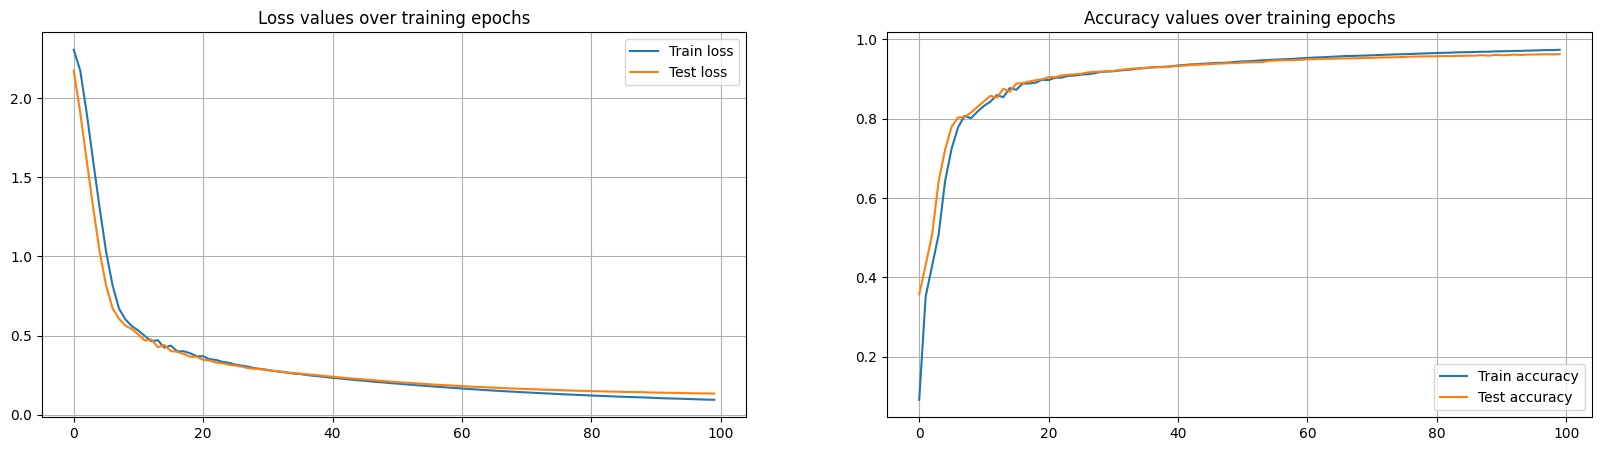

In [51]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range, train_losses, test_losses, train_acc, test_acc, figsize=(20, 5)
)

## Rede neural from scratch

A implementação da rede neural do zero foi feita de forma a se assemelhar à implementação do PyTorch. Abaixo estão listadas as diferentes separações das funções:

- _Funções matemáticas_:
  - `relu`: computa a função $ReLU$ (_Rectified Linear Unit_).
  - `d_relu_dx`: computa a derivada da função $ReLU$: $\frac{d\ ReLU}{dx}$.
  - `softmax`: computa a função $Softmax$.
- _Codificação_:
  - `one_hot`: faz codificação _One-Hot_ em um array linha.
- _Rede Neural_:
  - `MNISTNeuralNet`: classe do algoritmo de rede neural.
  - `backpropagation`: computa as derivadas parciais dos atributos da classe acima, e os atualiza.
  - `compute_loss`: computa o valor da perda usando $Categorical \ Cross$-$Entropy$.
- _Treinamento e Teste_:
  - `train_mnist`: função para treinar rede neural `MNISTNeuralNet`.
  - `test_prediction`: função para prever o valor de uma imagem e a imprimir.

Abaixo estão explicadas mais afundo a classe `MNISTNeuralNet`, e a função `backpropagation`.

### `MNISTNeuralNet`

A classe `MNISTNeuralNet`, inicializada apenas com um `learning_rate`, possui apenas duas camadas, cada uma com uma matriz de pesos (`self.w_n`) e outra de vieses (`self.b_n`). Ambos os tipos de matriz são inicializados com valores aleatórios provenientes de uma distribuição uniforme entre $0$ e $1$ com `np.random.rand`. A matriz de peso da primeira camada tem formato $10\times784$ para lidar com os valores iniciais, enquanto a segunda tem formato $10\times10$ correspondendo às $10$ diferentes classes (dígitos de $0$-$9$).

Possui apenas 1 método não mágico, `forward`, que faz a passagem de um array `x` através das camadas, fazendo também a passagem por uma função de ativação `relu`.

Seu outro método é uma implementação de `__call__` possibilitando a previsão de dados apenas chamando a instância e passando um array `x`, de forma similar ao PyTorch.

### `backpropagation`

Essa função, juntamente com a classe `MNISTNeuralNet` são as peças essenciais para o funcionamento da rede neural, vez que essa função é a responsável pela atualização das matrizes de pesos e vieses da rede neural. Ela faz a codificação das labels, em seguida calcula a derivada parcial de cada matriz, e atualiza os parâmetros da rede.


### Definindo funções e classe


#### Funções matemáticas


In [52]:
# ReLU activation function
def relu(Z: np.ndarray) -> np.ndarray:
    return np.maximum(0, Z)

In [53]:
# Derivative of ReLU
def d_relu_dx(Z: np.ndarray) -> np.ndarray:
    return Z > 0

In [54]:
# Softmax
def softmax(Z: np.ndarray) -> np.ndarray:
    return np.exp(Z) / np.sum(np.exp(Z), axis=0)

In [55]:
# Acurácia
def mnist_accuracy(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    return np.sum(y_pred == y_true) / y_true.size

#### Codificação


In [56]:
# Função para codificação One-Hot
def one_hot(y: np.ndarray) -> np.ndarray:
    one_hot_y = np.zeros((y.size, y.max() + 1))
    one_hot_y[np.arange(y.size), y] = 1

    return one_hot_y.T

#### Rede neural


In [ ]:
# Classe da rede neural
class MNISTNeuralNet:
    def __init__(self, learning_rate: float) -> None:
        # Learning rate
        self.learning_rate = learning_rate

        # First layers weights and biases
        self.w_1 = np.random.rand(10, 784) - 0.5
        self.b_1 = np.random.rand(10, 1) - 0.5

        # Second layers weights and biases
        self.w_2 = np.random.rand(10, 10) - 0.5
        self.b_2 = np.random.rand(10, 1) - 0.5

    def __call__(self, *args, **kwds) -> None:
        return self.forward(*args, **kwds)

    def forward(self, x: np.ndarray) -> None:
        # First layer neurons output and activation
        self.z_1 = self.w_1.dot(x) + self.b_1
        self.a_1 = relu(self.z_1)

        # Second layer neurons output and activation
        self.z_2 = self.w_2.dot(self.a_1) + self.b_2
        self.a_2 = softmax(self.z_2)

In [ ]:
# Função para cálculo de backpropagation
def back_propagation(
    estimator: MNISTNeuralNet,
    x: np.ndarray,
    y: np.ndarray,
) -> list[np.ndarray]:
    one_hot_y = one_hot(y)

    dz_2 = (1 / x.shape[1]) * (estimator.a_2 - one_hot_y)
    dw_2 = dz_2.dot(estimator.a_1.T)
    db_2 = np.sum(dz_2, axis=1).reshape(-1, 1)

    dz_1 = estimator.w_2.T.dot(dz_2) * d_relu_dx(estimator.z_1)
    dw_1 = dz_1.dot(x.T)
    db_1 = np.sum(dz_1, axis=1).reshape(-1, 1)

    estimator.w_1 -= estimator.learning_rate * dw_1
    estimator.b_1 -= estimator.learning_rate * db_1
    estimator.w_2 -= estimator.learning_rate * dw_2
    estimator.b_2 -= estimator.learning_rate * db_2

In [ ]:
# Função para calcular perda por Categorical cross entropy
def compute_loss(y_preds: np.ndarray, y_true: np.ndarray) -> float:
    one_hot_y = one_hot(y_true)
    log_probs = np.log(y_preds + 1e-10)

    return -np.sum(one_hot_y * log_probs) / y_true.size

#### Treinamento e teste


In [ ]:
# Função para fazer treinamento de rede neural
def train_mnist(
    estimator: MNISTNeuralNet,
    epochs: int,
    train_data: Tuple[np.ndarray, np.ndarray],
    validation_split: float | None = None,
    seed: int = None,
    print_every: int = 1,
) -> Dict[str, List[float]]:

    if seed is not None:
        torch.manual_seed(seed)

    X_train, y_train = train_data
    if validation_split is not None:
        X_train, X_val, y_train, y_val = train_test_split(
            X_train,
            y_train,
            test_size=validation_split,
            random_state=seed,
        )
        X_val = X_val.T
    X_train = X_train.T

    data_tracking = {
        'train_loss': [],
        'train_metric': [],
        'val_loss': [],
        'val_metric': [],
    }

    validation_print = ''
    val_metric_print = ''

    for epoch in range(epochs):
        estimator(X_train)
        train_preds = np.argmax(estimator.a_2, 0)

        training_loss = compute_loss(estimator.a_2, y_train)
        data_tracking['train_loss'].append(training_loss)

        training_metric = mnist_accuracy(y_pred=train_preds, y_true=y_train)
        data_tracking['train_metric'].append(training_metric)

        back_propagation(estimator=estimator, x=X_train, y=y_train)
        if validation_split is not None:
            estimator(X_val)
            val_preds = np.argmax(estimator.a_2, 0)
            validation_loss = compute_loss(val_preds, y_val)
            data_tracking['val_loss'].append(validation_loss)

            validation_metric = mnist_accuracy(val_preds, y_val)
            data_tracking['val_metric'].append(validation_metric)

            val_metric_print = f' Validation accuracy: {validation_metric:.2f} |'

            validation_print = f' Validation loss: {validation_loss:.2f} |'

        train_metric_print = f' Training accuracy: {training_metric:.2f} |'

        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(
                f'| Epoch: {epoch + 1} |',
                '-' * 101,
                f'| Training loss: {training_loss:.2f} |'
                + train_metric_print
                + validation_print
                + val_metric_print,
                '-' * 101,
                sep='\n',
                end='\n\n',
            )

    return data_tracking

In [ ]:
# Função que prevê um número baseado em uma imagem e a imprime
def test_prediction(
    estimator: MNISTNeuralNet,
    data: Tuple[np.ndarray, np.ndarray],
) -> None:
    x, y = data

    index = np.random.randint(1, x.shape[1])
    current_image = x[:, index, None]

    estimator(x[:, index, None])
    prediction = np.argmax(estimator.a_2, 0)

    label = y[index]

    print('Prediction: ', prediction.item())
    print('Label:      ', label)

    current_image = current_image.reshape(28, 28)
    plt.imshow(current_image, cmap='gray')
    plt.axis('off')
    plt.show()

### Treinando e validando modelo


In [ ]:
# Instanciando classe
neural_net = MNISTNeuralNet(learning_rate=0.05)

# Treinando modelo
mnist_history = train_mnist(
    estimator=neural_net,
    epochs=10000,
    train_data=(X_train, y_train),
    validation_split=0.2,
    print_every=1000,
)

| Epoch: 1 |
-----------------------------------------------------------------------------------------------------
| Training loss: 3.72 | Training accuracy: 0.10 | Validation loss: -1.09 | Validation accuracy: 0.10 |
-----------------------------------------------------------------------------------------------------

| Epoch: 1000 |
-----------------------------------------------------------------------------------------------------
| Training loss: 0.48 | Training accuracy: 0.85 | Validation loss: 1.06 | Validation accuracy: 0.85 |
-----------------------------------------------------------------------------------------------------

| Epoch: 2000 |
-----------------------------------------------------------------------------------------------------
| Training loss: 0.40 | Training accuracy: 0.88 | Validation loss: 1.05 | Validation accuracy: 0.88 |
-----------------------------------------------------------------------------------------------------

| Epoch: 3000 |
-----------------

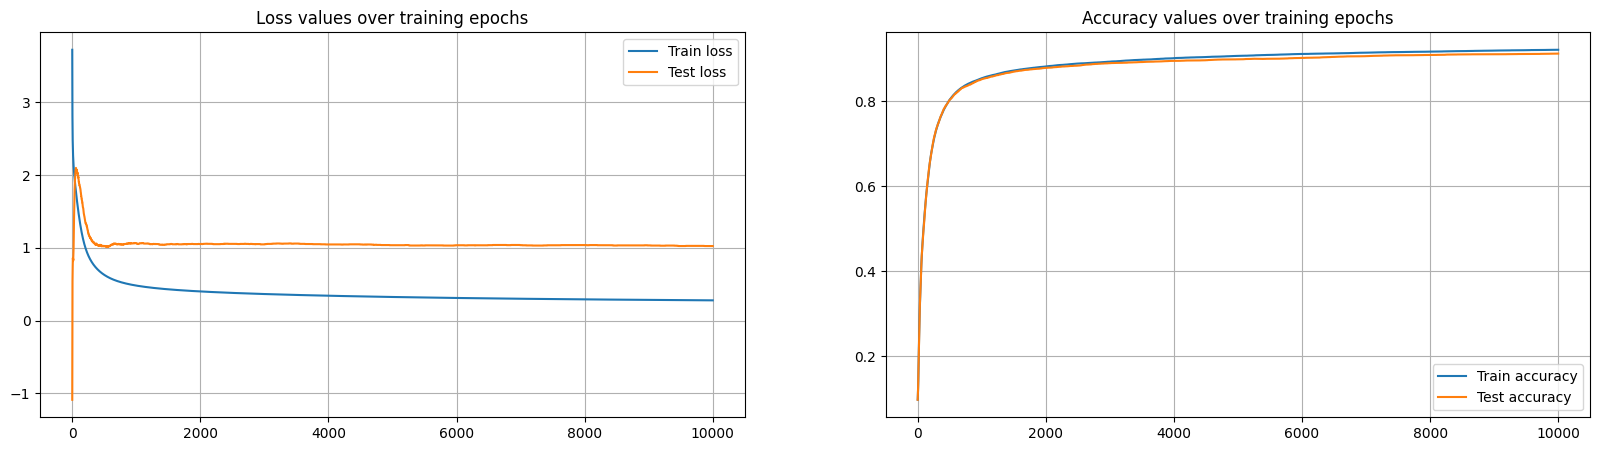

In [ ]:
# Criando range de época
epoch_range = [i for i in range(10000)]

# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range,
    train_losses=mnist_history['train_loss'],
    test_losses=mnist_history['val_loss'],
    train_acc=mnist_history['train_metric'],
    test_acc=mnist_history['val_metric'],
    figsize=(20, 5),
)

Prediction:  5
Label:       5


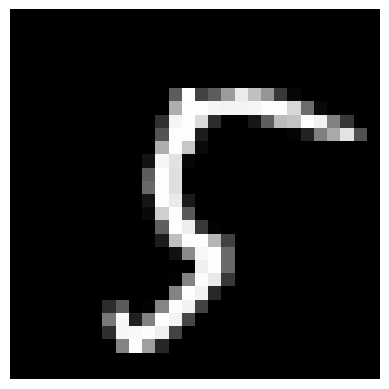

In [66]:
# Visualizando previsões
test_prediction(estimator=neural_net, data=(X_test.T, y_test))